In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
361,15778830,Female,53,34000,1
290,15586757,Male,39,134000,1
67,15654574,Female,23,82000,0
283,15663249,Female,52,21000,1
160,15744279,Male,32,100000,1


In [3]:
df = df.iloc[:,2:]
df.sample(5)

,Age,EstimatedSalary,Purchased
369,54,26000,1
373,59,130000,1
100,27,88000,0
256,41,72000,0
6,27,84000,0


# train_test_split

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis = 1), 
                                                    df['Purchased'], 
                                                    test_size=0.3, 
                                                    random_state=0
                                                   ) 
X_train.shape, X_test.shape

((280, 2), (120, 2))

# StandardScaler

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X_train)   # learn from train and transform both

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [7]:
type(X_train_scaled)

numpy.ndarray

In [8]:
# transform np array to pandas dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [9]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


# Effect of Scaling

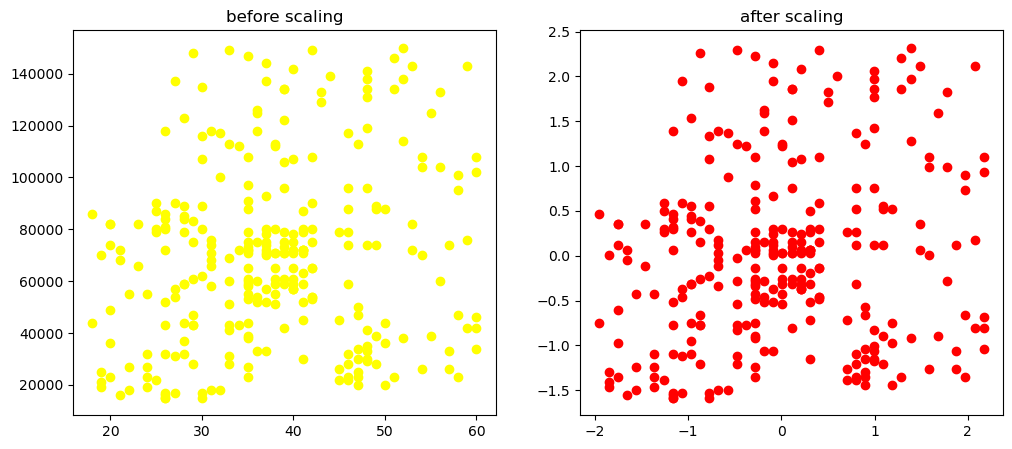

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(data = X_train, x='Age', y='EstimatedSalary', color='yellow')
ax1.set_title('before scaling')
ax2.scatter(data = X_train_scaled, x='Age', y='EstimatedSalary', color='red')
ax2.set_title('after scaling')
plt.show()

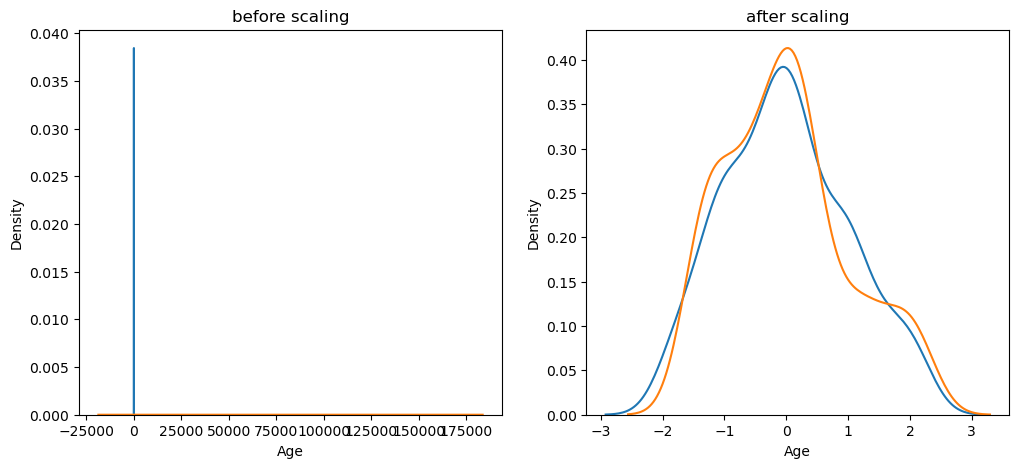

In [11]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# before scaling
ax1.set_title('before scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('after scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

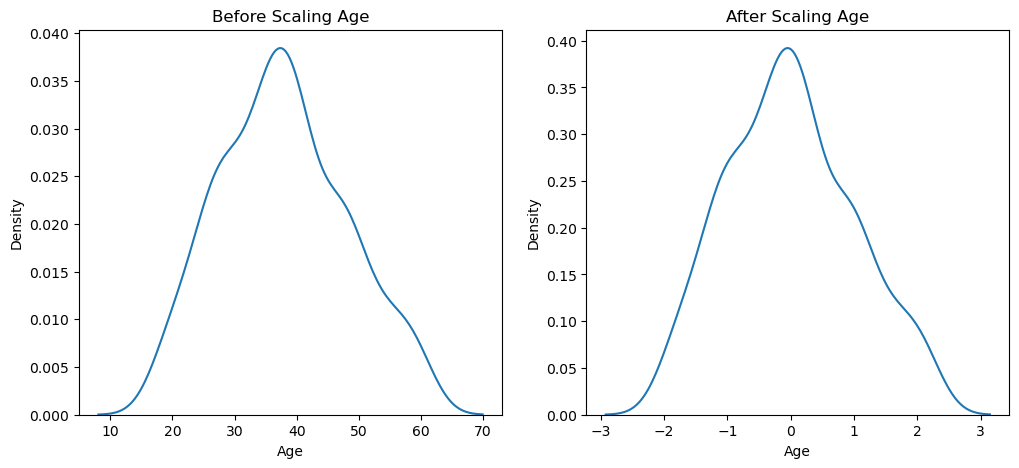

In [12]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title('Before Scaling Age')
sns.kdeplot(X_train['Age'], ax=ax1)
ax2.set_title('After Scaling Age')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

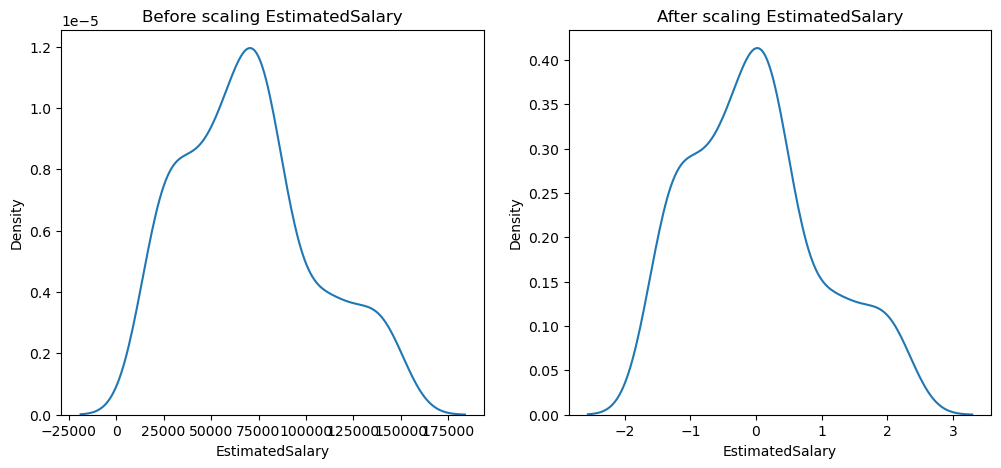

In [13]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title('Before scaling EstimatedSalary')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)
ax2.set_title('After scaling EstimatedSalary')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

## Why scaling important?

### 1. Logistic regression

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [16]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [17]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [18]:
from sklearn.metrics import accuracy_score
lr_acc = accuracy_score(y_pred, y_test)
lr_acc_scaled = accuracy_score(y_pred_scaled, y_test)
lr_acc, lr_acc_scaled

(0.6583333333333333, 0.8666666666666667)

### 2. decision tree

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [21]:
dt.fit(X_train, y_train)
dt_scaled.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [22]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [23]:
dt_acc = accuracy_score(y_test, y_pred)
dt_acc_scaled = accuracy_score(y_test, y_pred_scaled)
dt_acc, dt_acc_scaled

(0.875, 0.8666666666666667)

 ## Effect of outliers

In [24]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [25]:
df = pd.concat([df, pd.DataFrame({'Age':[5,90,95], 'EstimatedSalary':[1000, 250000, 350000], 'Purchased':[0,1,1]})], ignore_index=True)

In [26]:
df.describe()

,Age,EstimatedSalary,Purchased
count,403.000000,403.000000,403.000000
mean,37.846154,70714.640199,0.359801
std,11.255343,37959.790969,0.480539
min,5.000000,1000.000000,0.000000
25%,29.500000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,95.000000,350000.000000,1.000000


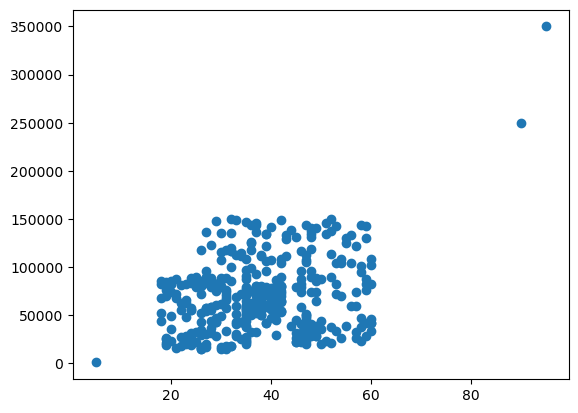

In [27]:
plt.scatter(df['Age'], df['EstimatedSalary'])